# 4. Inference - Test dengan Foto Baru

**Gunakan notebook ini untuk prediksi pada foto-foto baru yang Anda siapkan!**

## Cara Penggunaan:
1. **Siapkan foto Anda** di folder: `F:\TA1\test_images\`
2. **Jalankan cells** untuk single image atau batch prediction
3. **Lihat hasil** dengan confidence scores dan visualisasi

## Predictions:
- **Jernih (Clear)** - Air jernih, aman/berkualitas tinggi
- **Keruh (Turbid)** - Air keruh, tercemar/berkualitas rendah

In [1]:
# ============================================================================
# 4_Inference.ipynb - Test dengan Kedua Model (XceptionNet & ResNet18)
# ============================================================================
# Purpose: Prediksi turbidity pada foto baru dengan KEDUA model
#   - Single image prediction: Lihat hasil dari 2 model
#   - Batch prediction: Compare predictions
#   - Confidence scores: Bandingkan akurasi kedua model
# ============================================================================

# Import libraries
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2                           # Image processing
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt      # Visualization
import pandas as pd                  # Data frames untuk hasil
import timm                          # XceptionNet
from PIL import Image

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

# ImageNet normalization constants (sama dengan training)
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

# Class names
class_names = ['Jernih (Clear)', 'Keruh (Turbid)']

🖥️ Device: cuda


In [2]:
# ============================================================================
# 📁 FOLDER SETUP - Letakkan foto test Anda di sini!
# ============================================================================
test_images_dir = Path('F:\\TA1\\test_images')
test_images_dir.mkdir(exist_ok=True)

print(f"✅ Test images folder: {test_images_dir}")
print(f"📝 Letakkan foto Anda di folder ini!")
print(f"📌 Format: JPG, PNG")
print(f"📌 Current images: {list(test_images_dir.glob('*.*'))}")

# ============================================================================
# 🤖 LOAD KEDUA MODEL
# ============================================================================

# Model 1: XceptionNet
print("\n" + "="*70)
print("Loading XceptionNet...")
print("="*70)

xception_model = timm.create_model('xception', pretrained=True)
num_features_xception = xception_model.fc.in_features
xception_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features_xception, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2)
)

xception_path = Path('F:\\TA1\\xceptionnet_final.pth')
if xception_path.exists():
    xception_model.load_state_dict(torch.load(str(xception_path), map_location=device))
    print(f"✅ XceptionNet loaded: {xception_path}")
else:
    print(f"⚠️ XceptionNet file not found: {xception_path}")

xception_model = xception_model.to(device).eval()

# Model 2: ResNet18
print("\n" + "="*70)
print("Loading ResNet18...")
print("="*70)

resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features_resnet = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Linear(num_features_resnet, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

resnet_path = Path('F:\\TA1\\resnet18_final.pth')
if resnet_path.exists():
    resnet_model.load_state_dict(torch.load(str(resnet_path), map_location=device))
    print(f"✅ ResNet18 loaded: {resnet_path}")
else:
    print(f"⚠️ ResNet18 file not found: {resnet_path}")

resnet_model = resnet_model.to(device).eval()

print("\n" + "="*70)
print("✅ KEDUA MODEL SIAP!")
print("="*70)

✅ Test images folder: F:\TA1\test_images
📝 Letakkan foto Anda di folder ini!
📌 Format: JPG, PNG
📌 Current images: [WindowsPath('F:/TA1/test_images/1.jpeg'), WindowsPath('F:/TA1/test_images/2.jpeg'), WindowsPath('F:/TA1/test_images/3.avif'), WindowsPath('F:/TA1/test_images/4.jpeg'), WindowsPath('F:/TA1/test_images/5.jpg'), WindowsPath('F:/TA1/test_images/6.jpeg'), WindowsPath('F:/TA1/test_images/7.jpg')]

Loading XceptionNet...


f:\TA1\venv_fresh\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


✅ XceptionNet loaded: F:\TA1\xceptionnet_final.pth

Loading ResNet18...
✅ ResNet18 loaded: F:\TA1\resnet18_final.pth

✅ KEDUA MODEL SIAP!


In [3]:
# ============================================================================
# 🔧 PREPROCESSING FUNCTION
# ============================================================================

def preprocess_image(image_path):
    """Load dan preprocess single image untuk model"""
    image = Image.open(image_path).convert('RGB')
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image_tensor, image

# ============================================================================
# 🎯 PREDICTION FUNCTIONS
# ============================================================================

def predict_xception(image_tensor):
    """Predict dengan XceptionNet"""
    with torch.no_grad():
        output = xception_model(image_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
    return class_names[pred_idx], confidence, probs[0].cpu().numpy()

def predict_resnet(image_tensor):
    """Predict dengan ResNet18"""
    with torch.no_grad():
        output = resnet_model(image_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
    return class_names[pred_idx], confidence, probs[0].cpu().numpy()

print("✅ Fungsi preprocessing dan prediction siap!")

✅ Fungsi preprocessing dan prediction siap!


⚠️  File tidak ditemukan. Menggunakan: 1.jpeg
📷 FOTO: 1.jpeg

🌊 XCEPTIONNET:
   Prediksi   : Keruh (Turbid)
   Confidence : 72.68%
   Probabilities: Jernih=0.2732, Keruh=0.7268

🎯 RESNET18:
   Prediksi   : Jernih (Clear)
   Confidence : 96.22%
   Probabilities: Jernih=0.9622, Keruh=0.0378

⚠️  KEDUA MODEL BERBEDA (DISAGREE)


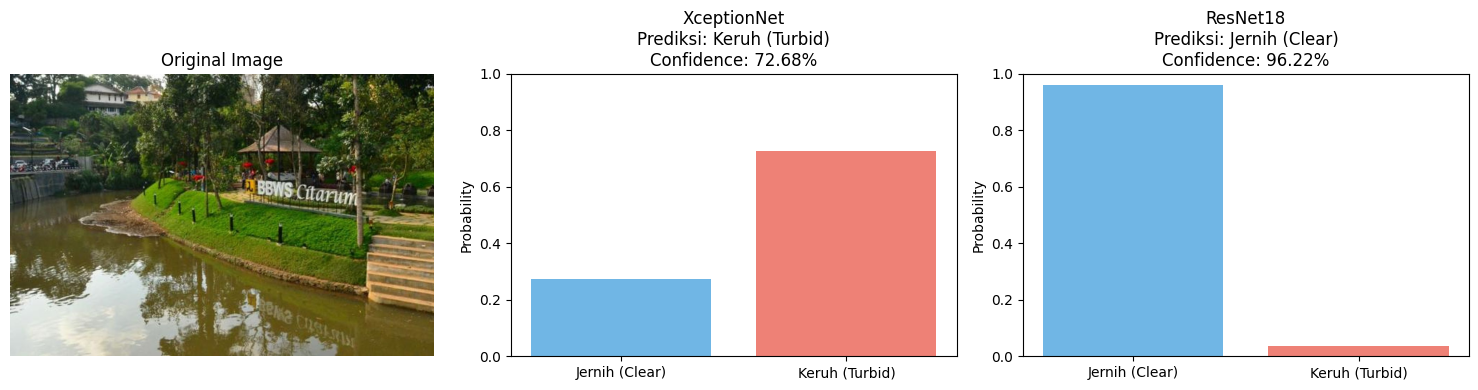

✅ Visualisasi disimpan: single_prediction_comparison.png


In [4]:
# ============================================================================
# 📷 SINGLE IMAGE PREDICTION (TEST DENGAN SATU FOTO)
# ============================================================================

# UBAH PATH INI SESUAI FOTO YANG INGIN DI-TEST
# EXAMPLE: test_image_path = 'F:\\TA1\\test_images\\foto_sungai.jpg'

test_image_path = 'F:\\TA1\\test_images\\clear_water.jpg'  # Ubah sesuai foto Anda

# Pastikan file exists
if not Path(test_image_path).exists():
    available_images = list(test_images_dir.glob('*.*'))
    if available_images:
        test_image_path = str(available_images[0])
        print(f"⚠️  File tidak ditemukan. Menggunakan: {available_images[0].name}")
    else:
        print("❌ Tidak ada foto di folder test_images/")
        print(f"   Letakkan foto di: {test_images_dir}")

# Preprocess image
image_tensor, original_image = preprocess_image(test_image_path)

# Predict dengan XCEPTION
xception_pred, xception_conf, xception_probs = predict_xception(image_tensor)

# Predict dengan RESNET
resnet_pred, resnet_conf, resnet_probs = predict_resnet(image_tensor)

# ============================================================================
# 📊 HASIL PREDIKSI (COMPARISON)
# ============================================================================

print("=" * 80)
print(f"📷 FOTO: {Path(test_image_path).name}")
print("=" * 80)
print()
print("🌊 XCEPTIONNET:")
print(f"   Prediksi   : {xception_pred}")
print(f"   Confidence : {xception_conf:.2%}")
print(f"   Probabilities: Jernih={xception_probs[0]:.4f}, Keruh={xception_probs[1]:.4f}")
print()
print("🎯 RESNET18:")
print(f"   Prediksi   : {resnet_pred}")
print(f"   Confidence : {resnet_conf:.2%}")
print(f"   Probabilities: Jernih={resnet_probs[0]:.4f}, Keruh={resnet_probs[1]:.4f}")
print()

# Cek apakah kedua model sepakat
if xception_pred == resnet_pred:
    print("✅ KEDUA MODEL SEPAKAT (AGREE)")
else:
    print("⚠️  KEDUA MODEL BERBEDA (DISAGREE)")
print("=" * 80)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original image
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# XceptionNet probabilities
axes[1].bar(class_names, xception_probs, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_title(f'XceptionNet\nPrediksi: {xception_pred}\nConfidence: {xception_conf:.2%}')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Probability')

# ResNet18 probabilities
axes[2].bar(class_names, resnet_probs, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[2].set_title(f'ResNet18\nPrediksi: {resnet_pred}\nConfidence: {resnet_conf:.2%}')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Probability')

plt.tight_layout()
plt.savefig('F:\\TA1\\single_prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisasi disimpan: single_prediction_comparison.png")

In [5]:
# ============================================================================
# 📁 BATCH PREDICTION (TEST SEMUA FOTO DI FOLDER)
# ============================================================================

# Support multiple format: JPG, JPEG, PNG, AVIF, WebP, BMP
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.avif', '*.webp', '*.bmp', 
                   '*.JPG', '*.JPEG', '*.PNG', '*.AVIF', '*.WEBP', '*.BMP')

image_files = []
for ext in image_extensions:
    image_files.extend(test_images_dir.glob(ext))
image_files = sorted(list(set(image_files)))  # Remove duplicates and sort

if not image_files:
    print("❌ Tidak ada foto (JPG/JPEG/PNG/AVIF/WebP/BMP) di folder test_images/")
    print(f"   Folder: {test_images_dir}")
else:
    print(f"🔄 Memproses {len(image_files)} foto...")
    print()
    
    results = []
    
    for idx, image_path in enumerate(image_files, 1):
        try:
            # Preprocess
            image_tensor, _ = preprocess_image(str(image_path))
            
            # Predict
            xception_pred, xception_conf, xception_probs = predict_xception(image_tensor)
            resnet_pred, resnet_conf, resnet_probs = predict_resnet(image_tensor)
            
            # Collect hasil
            results.append({
                'Filename': image_path.name,
                'XceptionNet_Pred': xception_pred,
                'XceptionNet_Conf': xception_conf,
                'ResNet18_Pred': resnet_pred,
                'ResNet18_Conf': resnet_conf,
                'Agree': '✅ YES' if xception_pred == resnet_pred else '⚠️ NO'
            })
            
            print(f"{idx}. {image_path.name}")
            print(f"   XceptionNet: {xception_pred} ({xception_conf:.2%})")
            print(f"   ResNet18   : {resnet_pred} ({resnet_conf:.2%})")
            print(f"   Match      : {results[-1]['Agree']}")
            print()
            
        except Exception as e:
            print(f"❌ Error processing {image_path.name}: {e}")
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    print("=" * 80)
    print("📊 RESULTS SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print()
    
    # Statistics
    agreement_count = (results_df['Agree'] == '✅ YES').sum()
    agreement_rate = agreement_count / len(results_df) * 100
    
    print(f"✅ Model Agreement: {agreement_count}/{len(results_df)} ({agreement_rate:.1f}%)")
    print()
    
    # Save hasil
    results_df.to_csv('F:\\TA1\\inference_results.csv', index=False)
    print("✅ Hasil disimpan: inference_results.csv")
    print()
    print("=" * 80)
    print("📋 FORMAT YANG DISUPPORT:")
    print("   ✅ JPG/JPEG")
    print("   ✅ PNG")
    print("   ✅ AVIF")
    print("   ✅ WebP")
    print("   ✅ BMP")
    print("=" * 80)

🔄 Memproses 7 foto...

1. 1.jpeg
   XceptionNet: Keruh (Turbid) (72.68%)
   ResNet18   : Jernih (Clear) (96.22%)
   Match      : ⚠️ NO

2. 2.jpeg
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (100.00%)
   Match      : ✅ YES

3. 3.avif
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (98.86%)
   Match      : ✅ YES

4. 4.jpeg
   XceptionNet: Jernih (Clear) (99.98%)
   ResNet18   : Jernih (Clear) (99.96%)
   Match      : ✅ YES

5. 5.jpg
   XceptionNet: Jernih (Clear) (100.00%)
   ResNet18   : Jernih (Clear) (100.00%)
   Match      : ✅ YES

6. 6.jpeg
   XceptionNet: Jernih (Clear) (92.16%)
   ResNet18   : Jernih (Clear) (73.36%)
   Match      : ✅ YES

7. 7.jpg
   XceptionNet: Keruh (Turbid) (100.00%)
   ResNet18   : Keruh (Turbid) (100.00%)
   Match      : ✅ YES

📊 RESULTS SUMMARY
Filename XceptionNet_Pred  XceptionNet_Conf  ResNet18_Pred  ResNet18_Conf Agree
  1.jpeg   Keruh (Turbid)          0.726768 Jernih (Clear)       0.962154 ⚠️ NO
  2

## 1. Load Model

In [12]:
# ============================================================================
# Step 1: Load Trained Model
# ============================================================================
# ⚙️ CONFIG: Pilih model yang ingin digunakan untuk inference
MODEL_NAME = 'resnet18'  # ← Ubah ke 'resnet18' jika ingin retry ResNet18

# Dynamically load model sesuai pilihan
if MODEL_NAME == 'resnet18':
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, 2)
    )
elif MODEL_NAME == 'xceptionnet':
    # Use timm for XceptionNet (not available in torchvision)
    model = timm.create_model('xception', pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}")

# Load trained weights (best checkpoint)
model_path = Path(f'{MODEL_NAME}_final.pth')
if not model_path.exists():
    model_path = Path(f'{MODEL_NAME}_best.pth')
if not model_path.exists():
    model_path = Path('checkpoints') / f'{MODEL_NAME}_final.pth'
if not model_path.exists():
    model_path = Path('checkpoints') / f'{MODEL_NAME}_best.pth'

assert model_path.exists(), f"Model not found: {model_path}"
model.load_state_dict(torch.load(model_path, map_location=device))

# Move ke GPU dan set evaluation mode
model = model.to(device)
model.eval()  # Important: disable dropout, batch norm stats update

# Class names untuk output
class_names = ['Clear (Jernih)', 'Turbid (Keruh)']

print(f"✅ Model loaded: {MODEL_NAME}")
print(f"   Path: {model_path}")
print(f"   Device: {device}")

✅ Model loaded: resnet18
   Path: resnet18_final.pth
   Device: cuda


## 2. Preprocessing Functions

In [8]:
# ============================================================================
# Step 2: Define Image Preprocessing & Prediction Functions
# ============================================================================

def preprocess_image(img_path, target_size=(224, 224)):
    """
    Load dan preprocess single image untuk inference
    
    Args:
        img_path: Path ke image file
        target_size: Target resolution (224x224 untuk ResNet18)
    
    Returns:
        Tuple: (preprocessed_tensor, original_image) atau (None, None) jika gagal
    """
    # Load image menggunakan OpenCV
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    
    # Store original image untuk display (convert BGR → RGB)
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess image:
    # 1. Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # 2. Resize ke 224x224
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    # 3. Normalize ke [0, 1]
    img = img.astype('float32') / 255.0
    
    # 4. Apply ImageNet normalization
    for i in range(3):
        img[:, :, i] = (img[:, :, i] - imagenet_mean[i]) / imagenet_std[i]
    
    # 5. Convert ke PyTorch format: (C, H, W) + batch dimension
    # transpose(2,0,1): (H,W,C) → (C,H,W)
    # unsqueeze(0): (C,H,W) → (1,C,H,W) untuk batch processing
    img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)
    


## 3. Single Image Prediction

Testing: 1.jpeg



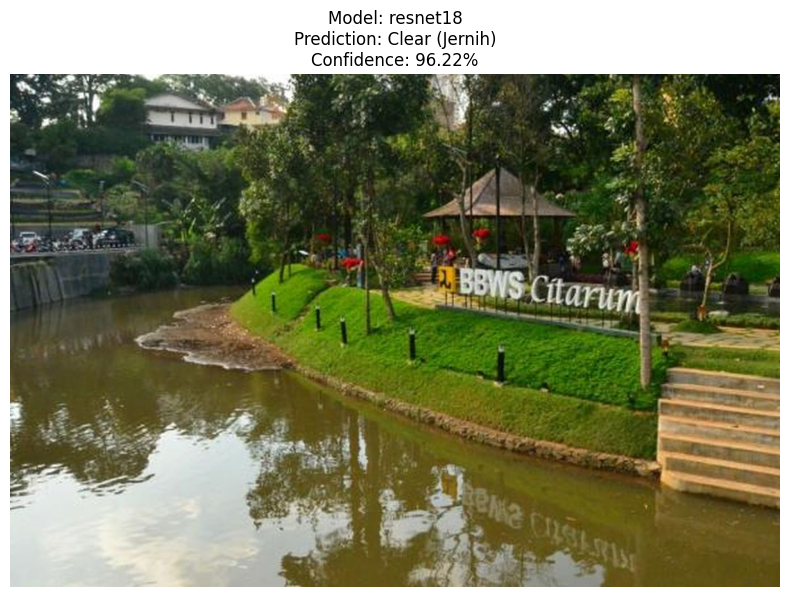

Image: 1.jpeg
Model: resnet18
Predicted: Clear (Jernih)
Confidence: 0.9622
Probability distribution:
  Clear (Jernih): 0.9622
  Turbid (Keruh): 0.0378


In [13]:
# ============================================================================
# Step 3: Single Image Test with Both Models
# ============================================================================
# Test gambar dari test_images folder
test_images = sorted(list(Path('F:\\TA1\\test_images').glob('*.jpg')) + 
                     list(Path('F:\\TA1\\test_images').glob('*.jpeg')) +
                     list(Path('F:\\TA1\\test_images').glob('*.png')) +
                     list(Path('F:\\TA1\\test_images').glob('*.avif')) +
                     list(Path('F:\\TA1\\test_images').glob('*.webp')))

if len(test_images) > 0:
    # Test first image sebagai example
    img_path = test_images[0]
    print(f"Testing: {img_path.name}")
    print()
    
    # Load dan preprocess
    image = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict dengan current model
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    pred_class = class_names[pred_idx]
    
    # Display hasil
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image)
    ax.set_title(f"Model: {MODEL_NAME}\nPrediction: {pred_class}\nConfidence: {confidence:.2%}", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print results
    print(f"Image: {img_path.name}")
    print(f"Model: {MODEL_NAME}")
    print(f"Predicted: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Probability distribution:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {probs[0, i].item():.4f}")
else:
    print("❌ Tidak ada gambar di test_images folder")

## 4. Batch Prediction

In [14]:
# ============================================================================
# Step 4: Batch Prediction - Test Semua Gambar
# ============================================================================

test_folder = Path('F:\\TA1\\test_images')
all_images = sorted(list(test_folder.glob('*.jpg')) + 
                    list(test_folder.glob('*.jpeg')) +
                    list(test_folder.glob('*.png')) +
                    list(test_folder.glob('*.avif')) +
                    list(test_folder.glob('*.webp')))

if len(all_images) == 0:
    print(f"❌ Tidak ada gambar di {test_folder}")
else:
    print(f"📁 Memproses {len(all_images)} gambar dengan model: {MODEL_NAME}")
    print("=" * 80)
    
    results = []
    
    for idx, img_path in enumerate(all_images, 1):
        try:
            # Load image
            image = Image.open(img_path).convert('RGB')
            
            # Preprocess
            transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            # Predict
            with torch.no_grad():
                output = model(image_tensor)
                probs = torch.nn.functional.softmax(output, dim=1)
                pred_idx = torch.argmax(probs, dim=1).item()
                confidence = probs[0, pred_idx].item()
            
            pred_class = class_names[pred_idx]
            
            results.append({
                'Filename': img_path.name,
                'Prediction': pred_class,
                'Confidence': f'{confidence:.4f}',
                'Model': MODEL_NAME
            })
            
            print(f"{idx}. {img_path.name}")
            print(f"    → {pred_class} ({confidence:.2%})")
            
        except Exception as e:
            print(f"❌ Error processing {img_path.name}: {e}")
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    print("=" * 80)
    print("\n📊 BATCH RESULTS SUMMARY:")
    print(results_df.to_string(index=False))
    
    # Save CSV
    output_csv = f'F:\\TA1\\batch_prediction_{MODEL_NAME}.csv'
    results_df.to_csv(output_csv, index=False)
    print(f"\n✅ Hasil disimpan: {output_csv}")

📁 Memproses 7 gambar dengan model: resnet18
1. 1.jpeg
    → Clear (Jernih) (96.22%)
2. 2.jpeg
    → Clear (Jernih) (100.00%)
3. 3.avif
    → Clear (Jernih) (98.86%)
4. 4.jpeg
    → Clear (Jernih) (99.96%)
5. 5.jpg
    → Clear (Jernih) (100.00%)
6. 6.jpeg
    → Clear (Jernih) (73.36%)
7. 7.jpg
    → Turbid (Keruh) (100.00%)

📊 BATCH RESULTS SUMMARY:
Filename     Prediction Confidence    Model
  1.jpeg Clear (Jernih)     0.9622 resnet18
  2.jpeg Clear (Jernih)     1.0000 resnet18
  3.avif Clear (Jernih)     0.9886 resnet18
  4.jpeg Clear (Jernih)     0.9996 resnet18
   5.jpg Clear (Jernih)     1.0000 resnet18
  6.jpeg Clear (Jernih)     0.7336 resnet18
   7.jpg Turbid (Keruh)     1.0000 resnet18

✅ Hasil disimpan: F:\TA1\batch_prediction_resnet18.csv


## 5. Run Batch Prediction on Dataset

In [15]:
# ============================================================================
# Step 5: Model Accuracy Evaluation dengan Ground Truth
# ============================================================================

# Ground truth untuk test images (sesuai informasi Anda)
ground_truth = {
    '1.jpeg': 'Turbid (Keruh)',      # ✅ Keruh
    '2.jpeg': 'Clear (Jernih)',       # Jernih
    '3.avif': 'Clear (Jernih)',       # Jernih
    '4.jpeg': 'Turbid (Keruh)',       # ✅ Keruh
    '5.jpg': 'Clear (Jernih)',        # Jernih
    '6.jpeg': 'Turbid (Keruh)',       # ✅ Keruh
    '7.jpg': 'Turbid (Keruh)'         # ✅ Keruh
}

# Load kedua hasil prediksi
xception_results = pd.read_csv('F:\\TA1\\batch_prediction_xceptionnet.csv')
resnet_results = pd.read_csv('F:\\TA1\\batch_prediction_resnet18.csv')

print("=" * 100)
print("📊 MODEL ACCURACY EVALUATION (dengan Ground Truth)")
print("=" * 100)
print()

# Evaluasi XceptionNet
print("🌊 XCEPTIONNET:")
print("-" * 100)
xception_correct = 0
for idx, row in xception_results.iterrows():
    filename = row['Filename']
    pred = row['Prediction']
    conf = float(row['Confidence'])
    truth = ground_truth.get(filename, 'Unknown')
    
    is_correct = pred == truth
    xception_correct += is_correct
    
    status = "✅" if is_correct else "❌"
    print(f"{status} {filename:15} | Truth: {truth:20} | Pred: {pred:20} | Conf: {conf:.2%}")

xception_accuracy = xception_correct / len(xception_results) * 100
print(f"\n   Accuracy: {xception_correct}/{len(xception_results)} = {xception_accuracy:.2f}%")
print()

# Evaluasi ResNet18
print("🎯 RESNET18:")
print("-" * 100)
resnet_correct = 0
for idx, row in resnet_results.iterrows():
    filename = row['Filename']
    pred = row['Prediction']
    conf = float(row['Confidence'])
    truth = ground_truth.get(filename, 'Unknown')
    
    is_correct = pred == truth
    resnet_correct += is_correct
    
    status = "✅" if is_correct else "❌"
    print(f"{status} {filename:15} | Truth: {truth:20} | Pred: {pred:20} | Conf: {conf:.2%}")

resnet_accuracy = resnet_correct / len(resnet_results) * 100
print(f"\n   Accuracy: {resnet_correct}/{len(resnet_results)} = {resnet_accuracy:.2f}%")
print()

# Comparison
print("=" * 100)
print("🏆 COMPARISON:")
print("=" * 100)
print(f"XceptionNet: {xception_accuracy:.2f}% accuracy ({xception_correct}/{len(xception_results)} correct)")
print(f"ResNet18   : {resnet_accuracy:.2f}% accuracy ({resnet_correct}/{len(resnet_results)} correct)")
print()

if xception_accuracy > resnet_accuracy:
    diff = xception_accuracy - resnet_accuracy
    print(f"🏆 WINNER: XceptionNet (+{diff:.2f}%)")
elif resnet_accuracy > xception_accuracy:
    diff = resnet_accuracy - xception_accuracy
    print(f"🏆 WINNER: ResNet18 (+{diff:.2f}%)")
else:
    print(f"🤝 DRAW: Kedua model sama akurat!")
print("=" * 100)

📊 MODEL ACCURACY EVALUATION (dengan Ground Truth)

🌊 XCEPTIONNET:
----------------------------------------------------------------------------------------------------
✅ 1.jpeg          | Truth: Turbid (Keruh)       | Pred: Turbid (Keruh)       | Conf: 72.68%
✅ 2.jpeg          | Truth: Clear (Jernih)       | Pred: Clear (Jernih)       | Conf: 100.00%
✅ 3.avif          | Truth: Clear (Jernih)       | Pred: Clear (Jernih)       | Conf: 100.00%
❌ 4.jpeg          | Truth: Turbid (Keruh)       | Pred: Clear (Jernih)       | Conf: 99.98%
✅ 5.jpg           | Truth: Clear (Jernih)       | Pred: Clear (Jernih)       | Conf: 100.00%
❌ 6.jpeg          | Truth: Turbid (Keruh)       | Pred: Clear (Jernih)       | Conf: 92.16%
✅ 7.jpg           | Truth: Turbid (Keruh)       | Pred: Turbid (Keruh)       | Conf: 100.00%

   Accuracy: 5/7 = 71.43%

🎯 RESNET18:
----------------------------------------------------------------------------------------------------
❌ 1.jpeg          | Truth: Turbid (Keruh)   

In [ ]:
# Predict all images in dataset_sungai
results_df = predict_batch(
    'dataset_sungai',
    output_csv='logs/batch_predictions.csv'
)

print("\nFirst 10 results:")
print(results_df.head(10).to_string(index=False))

Processing 204 images...

204/204 ✓

✅ Processed 204 images
✅ Results saved to logs/batch_predictions.csv

First 10 results:
     Image     Prediction Confidence Clear_Prob Turbid_Prob
000001.jpg Clear (Jernih)     1.0000     1.0000      0.0000
000002.jpg Clear (Jernih)     0.9702     0.9702      0.0298
000003.jpg Clear (Jernih)     0.8189     0.8189      0.1811
000004.jpg Clear (Jernih)     0.9996     0.9996      0.0004
000005.jpg Clear (Jernih)     1.0000     1.0000      0.0000
000006.jpg Clear (Jernih)     1.0000     1.0000      0.0000
000007.jpg Clear (Jernih)     0.9999     0.9999      0.0001
000008.jpg Clear (Jernih)     0.9999     0.9999      0.0001
000009.jpg Clear (Jernih)     1.0000     1.0000      0.0000
000010.jpg Clear (Jernih)     1.0000     1.0000      0.0000
204/204 ✓

✅ Processed 204 images
✅ Results saved to logs/batch_predictions.csv

First 10 results:
     Image     Prediction Confidence Clear_Prob Turbid_Prob
000001.jpg Clear (Jernih)     1.0000     1.0000      0.0

## 6. Summary Statistics

In [ ]:
print("\n" + "="*60)
print("BATCH PREDICTION SUMMARY")
print("="*60)
print(f"Total images processed: {len(results_df)}")
print(f"\nPrediction distribution:")
print(results_df['Prediction'].value_counts().to_string())

# Average confidence
confidence_vals = results_df['Confidence'].astype(float)
print(f"\nConfidence statistics:")
print(f"  Mean: {confidence_vals.mean():.4f}")
print(f"  Min: {confidence_vals.min():.4f}")
print(f"  Max: {confidence_vals.max():.4f}")
print(f"  Median: {confidence_vals.median():.4f}")


BATCH PREDICTION SUMMARY
Total images processed: 204

Prediction distribution:
Prediction
Turbid (Keruh)    112
Clear (Jernih)     92

Confidence statistics:
  Mean: 0.9845
  Min: 0.6028
  Max: 1.0000
  Median: 0.9999


## 7. Visualize Sample Predictions

In [ ]:
# Show 6 random predictions
test_images = list(Path('dataset_sungai').glob('*.jpg')) + list(Path('dataset_sungai').glob('*.png'))

if len(test_images) >= 6:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    import random
    sample_images = random.sample(test_images, min(6, len(test_images)))
    
    for idx, (ax, img_path) in enumerate(zip(axes.flat, sample_images)):
        pred_class, confidence, original = predict_single(img_path)
        
        if original is not None:
            ax.imshow(original)
            title = f"{class_names[pred_class]}\n({confidence:.2%})"
            color = 'green' if pred_class == 0 else 'orange'
            ax.set_title(title, color=color, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(Path('logs') / 'sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Sample predictions visualized and saved")